BEAMFORMING: DAS и MVDR

Параметры:
  Частота сигнала: 440 Гц
  Угол источника: 30°
  Шаг решетки: 20 см
  SNR: 30 дБ
Координаты микрофонов: [-0.7 -0.5 -0.3 -0.1  0.1  0.3  0.5  0.7]

Размерность X: (8, 9600)
Теоретическая задержка (крайние): 0.002059 с
DAS
Оцененный угол (DAS): 29.50°
Ошибка: 0.50°
MVDR
Оцененный угол (MVDR): 29.50°
Ошибка: 0.50°

Построение графиков...


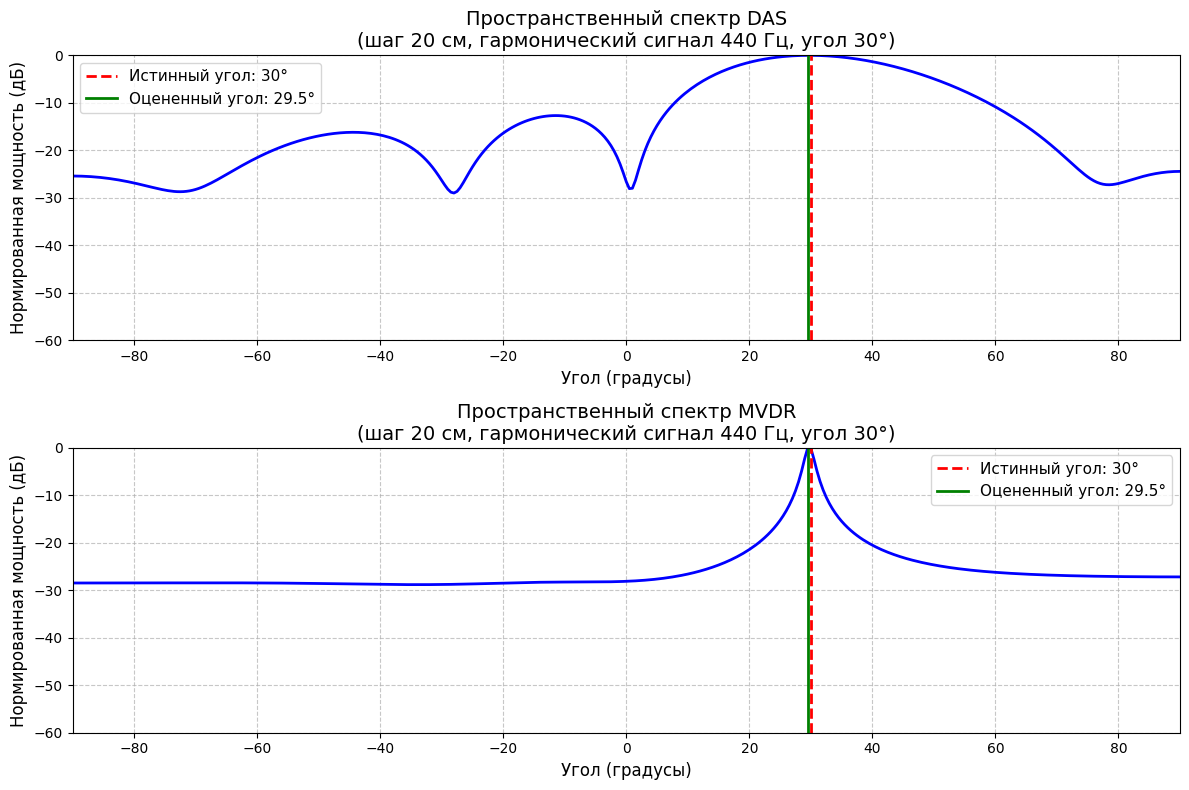

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, irfft

np.random.seed(42)

# 1. Генерация сигналов

def generate_harmonic_signal(fs, T, f0, A=1.0):
    """Генерация гармонического сигнала"""
    t = np.arange(0, T, 1/fs)
    s = A * np.cos(2 * np.pi * f0 * t)
    return t, s

def generate_array_signals(s, t, d, theta, R=3.0, SNR_dB=30, c=340, fs=None):
    """Генерация сигналов на микрофонах с задержкой"""
    M = len(d)
    L = len(s)
    theta_rad = np.deg2rad(theta)
    tau = d * np.sin(theta_rad) / c

    tau_samples = tau * fs
    delay_samples = np.round(tau_samples).astype(int)

    attenuation = 1.0 / R
    X = np.zeros((M, L))

    for m in range(M):
        s_delayed = np.zeros_like(s)
        delay = delay_samples[m]

        if delay >= 0:
            if delay > 0:
                s_delayed[delay:] = s[:-delay]
            else:
                s_delayed[:] = s[:]
        else:
            delay_abs = abs(delay)
            if delay_abs > 0:
                s_delayed[:-delay_abs] = s[delay_abs:]
            else:
                s_delayed[:] = s[:]

        signal_power = np.mean(s_delayed**2)
        if signal_power < 1e-12:
            signal_power = 1.0
        noise_power = signal_power / (10**(SNR_dB/10))
        noise = np.sqrt(noise_power) * np.random.randn(L)

        X[m, :] = attenuation * s_delayed + noise

    return X, tau

# 2. Вспомогательные функции

def compute_steering_vector(d, theta, f0, c=340):
    """
    Вычисление вектора направлений для линейной решетки.

    Параметры:
        d : ndarray (M) — координаты микрофонов (м)
        theta : float — угол прихода (градусы)
        f0 : float — частота сигнала (Гц)
        c : float — скорость звука (м/с)

    Возвращает:
        a : ndarray (M) — комплексный вектор направлений
    """
    theta_rad = np.deg2rad(theta)
    a = np.exp(-1j * 2 * np.pi * f0 * d * np.sin(theta_rad) / c)
    return a

def compute_covariance_matrix(X):
    """
    Вычисление выборочной ковариационной матрицы сигналов.
    """
    M = X.shape[0]
    L = X.shape[1]

    # преобразование в комплексную огибающую
    X_complex = np.zeros((M, L), dtype=complex)
    for m in range(M):
        X_fft = np.fft.fft(X[m, :])
        X_fft[L//2+1:] = 0
        X_complex[m, :] = np.fft.ifft(X_fft)

    R = np.zeros((M, M), dtype=complex)
    for n in range(L):
        x = X_complex[:, n]
        R += np.outer(x, np.conj(x))
    R /= L

    return R

# 3. Метод DAS

def das_beamformer(X, d, theta_range, fs, c=340):

    M = X.shape[0]
    L = X.shape[1]
    N_theta = len(theta_range)

    R = compute_covariance_matrix(X)

    spectrum = np.zeros(N_theta)

    for i, theta in enumerate(theta_range):
        # steering vector на частоте сигнала
        f0 = 440  # частота сигнала
        a = compute_steering_vector(d, theta, f0, c)
        P = np.real(np.conj(a).T @ R @ a)
        spectrum[i] = P

    # нормирование
    spectrum = spectrum / np.max(spectrum)

    # оценка угла
    idx_max = np.argmax(spectrum)
    theta_est = theta_range[idx_max]

    return spectrum, theta_est

# 4. Метод MVDR

def mvdr_beamformer(X, d, theta_range, f0, c=340, reg=1e-6):

    M = X.shape[0]
    N_theta = len(theta_range)
    R = compute_covariance_matrix(X)
    R += reg * np.trace(R) * np.eye(M)
    R_inv = np.linalg.pinv(R)
    spectrum = np.zeros(N_theta)

    for i, theta in enumerate(theta_range):
        a = compute_steering_vector(d, theta, f0, c)
        denominator = np.real(np.conj(a).T @ R_inv @ a)
        if denominator > 1e-12:
            spectrum[i] = 1.0 / denominator
        else:
            spectrum[i] = 1e-12

    # нормирование
    spectrum = spectrum / np.max(spectrum)

    # оценка угла
    idx_max = np.argmax(spectrum)
    theta_est = theta_range[idx_max]

    return spectrum, theta_est

# 5. Функция для поиска пиков

def find_peaks_spectrum(spectrum, theta_range, n_peaks=3, height_threshold=0.1):

    from scipy.signal import find_peaks

    peaks, properties = find_peaks(spectrum, height=height_threshold * np.max(spectrum))

    if len(peaks) == 0:
        return []

    heights = properties['peak_heights']
    sorted_idx = np.argsort(heights)[::-1]
    top_peaks = peaks[sorted_idx[:n_peaks]]

    angles = theta_range[top_peaks]
    return angles

# 6. Пример использования

if __name__ == "__main__":
    print("BEAMFORMING: DAS и MVDR")

    fs = 48000
    T = 0.2
    M = 8
    delta_d = 0.20
    theta_true = 30
    R = 3.0
    SNR_dB = 30
    f0 = 440
    c = 340

    print(f"\nПараметры:")
    print(f"  Частота сигнала: {f0} Гц")
    print(f"  Угол источника: {theta_true}°")
    print(f"  Шаг решетки: {delta_d*100:.0f} см")
    print(f"  SNR: {SNR_dB} дБ")

    # координаты микрофонов
    d = (np.arange(M) - (M - 1) / 2) * delta_d
    print(f"Координаты микрофонов: {d}")

    # генерация сигналов
    t, s = generate_harmonic_signal(fs, T, f0)
    X, tau_true = generate_array_signals(s, t, d, theta_true, R, SNR_dB, fs=fs, c=c)

    print(f"\nРазмерность X: {X.shape}")
    print(f"Теоретическая задержка (крайние): {tau_true[-1] - tau_true[0]:.6f} с")

    # сканирование углов
    theta_range = np.linspace(-90, 90, 361)

    print("DAS")

    spectrum_das, theta_das = das_beamformer(X, d, theta_range, fs, c)

    print(f"Оцененный угол (DAS): {theta_das:.2f}°")
    print(f"Ошибка: {abs(theta_das - theta_true):.2f}°")

    print("MVDR")

    spectrum_mvdr, theta_mvdr = mvdr_beamformer(X, d, theta_range, f0, c, reg=1e-6)

    print(f"Оцененный угол (MVDR): {theta_mvdr:.2f}°")
    print(f"Ошибка: {abs(theta_mvdr - theta_true):.2f}°")

    # Визуализация
    print("\nПостроение графиков...")

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # DAS
    axes[0].plot(theta_range, 10 * np.log10(spectrum_das + 1e-12), 'b-', linewidth=2)
    axes[0].axvline(theta_true, color='r', linestyle='--', linewidth=2,
                    label=f'Истинный угол: {theta_true}°')
    axes[0].axvline(theta_das, color='g', linestyle='-', linewidth=2,
                    label=f'Оцененный угол: {theta_das:.1f}°')
    axes[0].set_xlabel('Угол (градусы)', fontsize=12)
    axes[0].set_ylabel('Нормированная мощность (дБ)', fontsize=12)
    axes[0].set_title('Пространственный спектр DAS\n(шаг 20 см, гармонический сигнал 440 Гц, угол 30°)', fontsize=14)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, linestyle='--', alpha=0.7)
    axes[0].set_xlim(-90, 90)
    axes[0].set_ylim(-60, 0)

    # MVDR
    axes[1].plot(theta_range, 10 * np.log10(spectrum_mvdr + 1e-12), 'b-', linewidth=2)
    axes[1].axvline(theta_true, color='r', linestyle='--', linewidth=2,
                    label=f'Истинный угол: {theta_true}°')
    axes[1].axvline(theta_mvdr, color='g', linestyle='-', linewidth=2,
                    label=f'Оцененный угол: {theta_mvdr:.1f}°')
    axes[1].set_xlabel('Угол (градусы)', fontsize=12)
    axes[1].set_ylabel('Нормированная мощность (дБ)', fontsize=12)
    axes[1].set_title('Пространственный спектр MVDR\n(шаг 20 см, гармонический сигнал 440 Гц, угол 30°)', fontsize=14)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    axes[1].set_xlim(-90, 90)
    axes[1].set_ylim(-60, 0)

    plt.tight_layout()
    plt.show()

BEAMFORMING: ДВА ИСТОЧНИКА (РАЗНЫЕ ЧАСТОТЫ, ШАГ 10 СМ)
  Источник 1: 440 Гц, угол 30°
  Источник 2: 880 Гц, угол -20°
  Шаг решетки: 10 см
  SNR: 30 дБ

Размерность X: (8, 9600)
ЧИСЛЕННЫЕ РЕЗУЛЬТАТЫ

DAS:
  Истинные углы: 30° (f=440 Гц), -20° (f=880 Гц)
  f=440 Гц: найденные пики [-45.  32.], ошибка для 30° = 2.00°
  f=880 Гц: найденные пики [-20.5  15.5], ошибка для -20° = 0.50°

MVDR:
  Истинные углы: 30° (f=440 Гц), -20° (f=880 Гц)
  f=440 Гц: найденные пики [ 30.5 -42.5], ошибка для 30° = 0.50°
  f=880 Гц: найденные пики [ 14.5 -20. ], ошибка для -20° = 0.00°

Построение графиков...


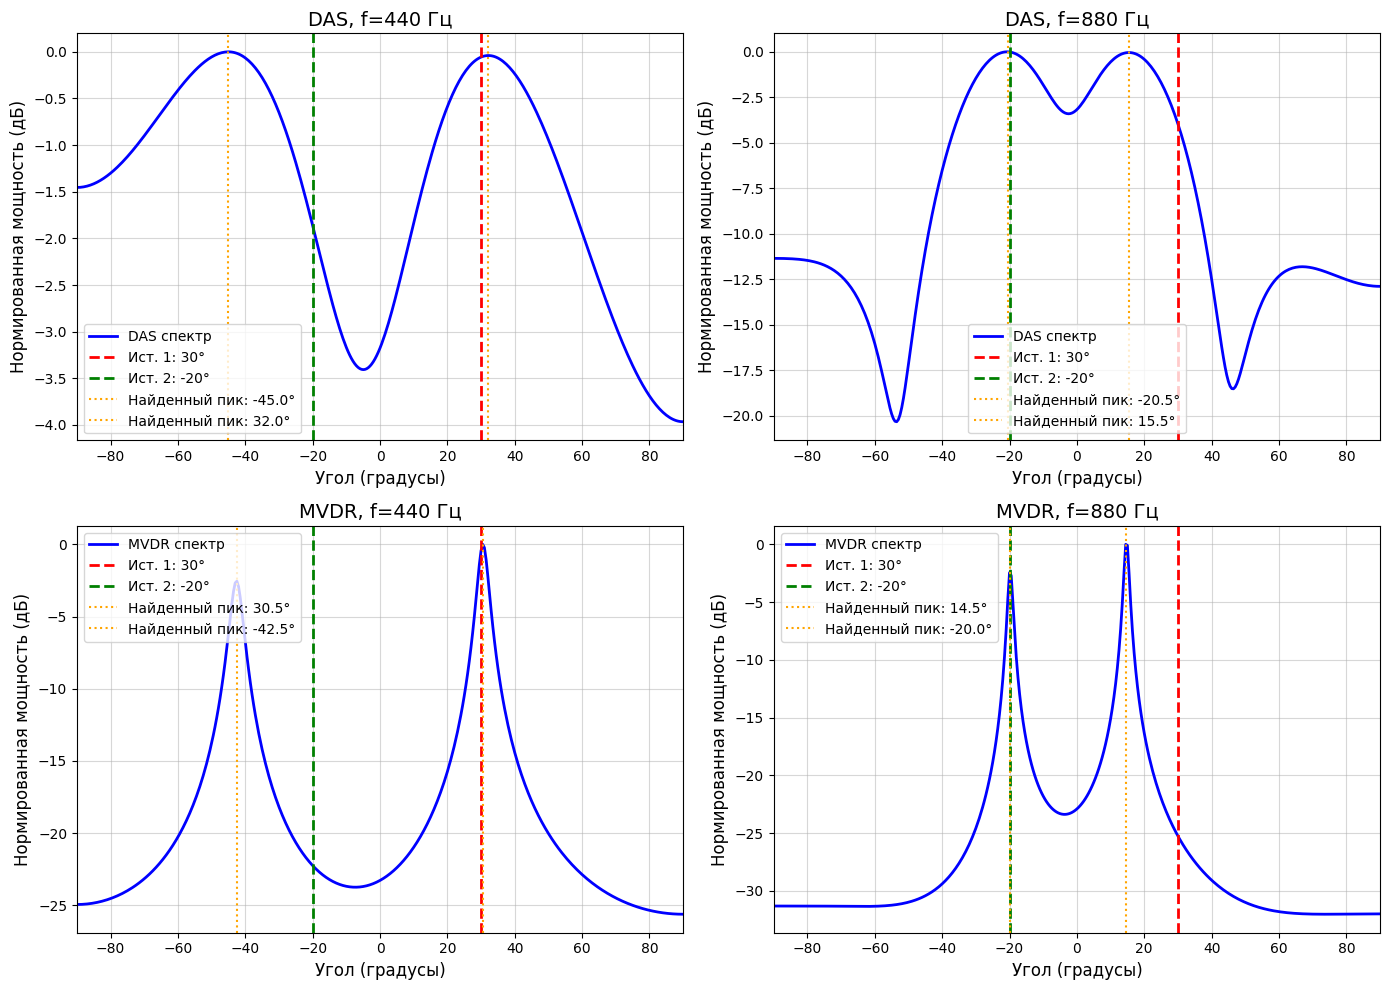

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

np.random.seed(42)

# 1. Генерация сигналов

def generate_harmonic_signal(fs, T, f0, A=1.0):
    t = np.arange(0, T, 1/fs)
    s = A * np.cos(2 * np.pi * f0 * t)
    return t, s

def generate_array_signals_two_sources(s1, s2, t, d, theta1, theta2, R=3.0, SNR_dB=30, c=340, fs=None):
    M = len(d)
    L = len(s1)

    theta1_rad = np.deg2rad(theta1)
    theta2_rad = np.deg2rad(theta2)

    tau1 = d * np.sin(theta1_rad) / c
    tau2 = d * np.sin(theta2_rad) / c

    tau1_samples = np.round(tau1 * fs).astype(int)
    tau2_samples = np.round(tau2 * fs).astype(int)

    attenuation = 1.0 / R
    X = np.zeros((M, L))

    for m in range(M):
        s1_delayed = np.zeros_like(s1)
        delay1 = tau1_samples[m]
        if delay1 >= 0:
            if delay1 > 0:
                s1_delayed[delay1:] = s1[:-delay1]
            else:
                s1_delayed[:] = s1[:]
        else:
            delay_abs = abs(delay1)
            if delay_abs > 0:
                s1_delayed[:-delay_abs] = s1[delay_abs:]
            else:
                s1_delayed[:] = s1[:]

        s2_delayed = np.zeros_like(s2)
        delay2 = tau2_samples[m]
        if delay2 >= 0:
            if delay2 > 0:
                s2_delayed[delay2:] = s2[:-delay2]
            else:
                s2_delayed[:] = s2[:]
        else:
            delay_abs = abs(delay2)
            if delay_abs > 0:
                s2_delayed[:-delay_abs] = s2[delay_abs:]
            else:
                s2_delayed[:] = s2[:]

        s_total = attenuation * (s1_delayed + s2_delayed)

        signal_power = np.mean(s_total**2)
        if signal_power < 1e-12:
            signal_power = 1.0
        noise_power = signal_power / (10**(SNR_dB/10))
        noise = np.sqrt(noise_power) * np.random.randn(L)

        X[m, :] = s_total + noise

    return X, tau1, tau2

# 2. Функции DAS и MVDR

def compute_steering_vector(d, theta, f0, c=340):
    theta_rad = np.deg2rad(theta)
    a = np.exp(-1j * 2 * np.pi * f0 * d * np.sin(theta_rad) / c)
    return a

def compute_covariance_matrix(X):
    M = X.shape[0]
    L = X.shape[1]

    X_complex = np.zeros((M, L), dtype=complex)
    for m in range(M):
        X_fft = np.fft.fft(X[m, :])
        X_fft[L//2+1:] = 0
        X_complex[m, :] = np.fft.ifft(X_fft)

    R = np.zeros((M, M), dtype=complex)
    for n in range(L):
        x = X_complex[:, n]
        R += np.outer(x, np.conj(x))
    R /= L

    return R

def das_beamformer(X, d, theta_range, f0, c=340):
    R = compute_covariance_matrix(X)
    N_theta = len(theta_range)

    spectrum = np.zeros(N_theta)
    for i, theta in enumerate(theta_range):
        a = compute_steering_vector(d, theta, f0, c)
        P = np.real(np.conj(a).T @ R @ a)
        spectrum[i] = P

    spectrum = spectrum / np.max(spectrum)
    return spectrum

def mvdr_beamformer(X, d, theta_range, f0, c=340, reg=1e-6):
    R = compute_covariance_matrix(X)
    R += reg * np.trace(R) * np.eye(M)
    R_inv = np.linalg.pinv(R)
    N_theta = len(theta_range)

    spectrum = np.zeros(N_theta)
    for i, theta in enumerate(theta_range):
        a = compute_steering_vector(d, theta, f0, c)
        denominator = np.real(np.conj(a).T @ R_inv @ a)
        if denominator > 1e-12:
            spectrum[i] = 1.0 / denominator
        else:
            spectrum[i] = 1e-12

    spectrum = spectrum / np.max(spectrum)
    return spectrum

def find_peaks_spectrum(spectrum, theta_range, n_peaks=2, height_threshold=0.1):
    peaks, properties = find_peaks(spectrum, height=height_threshold * np.max(spectrum))
    if len(peaks) == 0:
        return []
    heights = properties['peak_heights']
    sorted_idx = np.argsort(heights)[::-1]
    top_peaks = peaks[sorted_idx[:n_peaks]]
    return theta_range[top_peaks]

# 3. Параметры

fs = 48000
T = 0.2
M = 8
delta_d = 0.10
theta1_true = 30
theta2_true = -20
R = 3.0
SNR_dB = 30
f1 = 440
f2 = 880
c = 340

print("BEAMFORMING: ДВА ИСТОЧНИКА (РАЗНЫЕ ЧАСТОТЫ, ШАГ 10 СМ)")
print(f"  Источник 1: {f1} Гц, угол {theta1_true}°")
print(f"  Источник 2: {f2} Гц, угол {theta2_true}°")
print(f"  Шаг решетки: {delta_d*100:.0f} см")
print(f"  SNR: {SNR_dB} дБ")

d = (np.arange(M) - (M - 1) / 2) * delta_d
theta_range = np.linspace(-90, 90, 361)

# генерация сигналов
t, s1 = generate_harmonic_signal(fs, T, f1)
t, s2 = generate_harmonic_signal(fs, T, f2)
X, tau1, tau2 = generate_array_signals_two_sources(
    s1, s2, t, d, theta1_true, theta2_true, R, SNR_dB, fs=fs, c=c
)

print(f"\nРазмерность X: {X.shape}")

# расчет спектров

# DAS
spectrum_das_f1 = das_beamformer(X, d, theta_range, f1, c)
spectrum_das_f2 = das_beamformer(X, d, theta_range, f2, c)
peaks_das_f1 = find_peaks_spectrum(spectrum_das_f1, theta_range, n_peaks=2)
peaks_das_f2 = find_peaks_spectrum(spectrum_das_f2, theta_range, n_peaks=2)

# MVDR
spectrum_mvdr_f1 = mvdr_beamformer(X, d, theta_range, f1, c)
spectrum_mvdr_f2 = mvdr_beamformer(X, d, theta_range, f2, c)
peaks_mvdr_f1 = find_peaks_spectrum(spectrum_mvdr_f1, theta_range, n_peaks=2)
peaks_mvdr_f2 = find_peaks_spectrum(spectrum_mvdr_f2, theta_range, n_peaks=2)

# численные результаты

print("ЧИСЛЕННЫЕ РЕЗУЛЬТАТЫ")

def print_results(method_name, peaks_f1, peaks_f2, f1, f2, theta1_true, theta2_true):
    print(f"\n{method_name}:")
    print(f"  Истинные углы: {theta1_true}° (f={f1} Гц), {theta2_true}° (f={f2} Гц)")

    # для частоты f1
    if len(peaks_f1) >= 1:
        # выбираем пик, ближайший к истинному углу 1
        error1_f1 = min(abs(p - theta1_true) for p in peaks_f1)
        print(f"  f={f1} Гц: найденные пики {peaks_f1}, ошибка для {theta1_true}° = {error1_f1:.2f}°")
    else:
        print(f"  f={f1} Гц: пики не найдены")

    # для частоты f2
    if len(peaks_f2) >= 1:
        error2_f2 = min(abs(p - theta2_true) for p in peaks_f2)
        print(f"  f={f2} Гц: найденные пики {peaks_f2}, ошибка для {theta2_true}° = {error2_f2:.2f}°")
    else:
        print(f"  f={f2} Гц: пики не найдены")

print_results("DAS", peaks_das_f1, peaks_das_f2, f1, f2, theta1_true, theta2_true)
print_results("MVDR", peaks_mvdr_f1, peaks_mvdr_f2, f1, f2, theta1_true, theta2_true)

# Визуализация
print("\nПостроение графиков...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# DAS f1
axes[0, 0].plot(theta_range, 10 * np.log10(spectrum_das_f1 + 1e-12), 'b-', linewidth=2, label='DAS спектр')
axes[0, 0].axvline(theta1_true, color='r', linestyle='--', linewidth=2, label=f'Ист. 1: {theta1_true}°')
axes[0, 0].axvline(theta2_true, color='g', linestyle='--', linewidth=2, label=f'Ист. 2: {theta2_true}°')
for peak in peaks_das_f1:
    axes[0, 0].axvline(peak, color='orange', linestyle=':', linewidth=1.5, label=f'Найденный пик: {peak:.1f}°')

handles, labels = axes[0, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0, 0].legend(by_label.values(), by_label.keys(), fontsize=10)
axes[0, 0].set_xlabel('Угол (градусы)', fontsize=12)
axes[0, 0].set_ylabel('Нормированная мощность (дБ)', fontsize=12)
axes[0, 0].set_title(f'DAS, f={f1} Гц', fontsize=14)
axes[0, 0].grid(True, alpha=0.5)
axes[0, 0].set_xlim(-90, 90)

# DAS f2
axes[0, 1].plot(theta_range, 10 * np.log10(spectrum_das_f2 + 1e-12), 'b-', linewidth=2, label='DAS спектр')
axes[0, 1].axvline(theta1_true, color='r', linestyle='--', linewidth=2, label=f'Ист. 1: {theta1_true}°')
axes[0, 1].axvline(theta2_true, color='g', linestyle='--', linewidth=2, label=f'Ист. 2: {theta2_true}°')
for peak in peaks_das_f2:
    axes[0, 1].axvline(peak, color='orange', linestyle=':', linewidth=1.5, label=f'Найденный пик: {peak:.1f}°')
handles, labels = axes[0, 1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0, 1].legend(by_label.values(), by_label.keys(), fontsize=10)
axes[0, 1].set_xlabel('Угол (градусы)', fontsize=12)
axes[0, 1].set_ylabel('Нормированная мощность (дБ)', fontsize=12)
axes[0, 1].set_title(f'DAS, f={f2} Гц', fontsize=14)
axes[0, 1].grid(True, alpha=0.5)
axes[0, 1].set_xlim(-90, 90)

# MVDR f1
axes[1, 0].plot(theta_range, 10 * np.log10(spectrum_mvdr_f1 + 1e-12), 'b-', linewidth=2, label='MVDR спектр')
axes[1, 0].axvline(theta1_true, color='r', linestyle='--', linewidth=2, label=f'Ист. 1: {theta1_true}°')
axes[1, 0].axvline(theta2_true, color='g', linestyle='--', linewidth=2, label=f'Ист. 2: {theta2_true}°')
for peak in peaks_mvdr_f1:
    axes[1, 0].axvline(peak, color='orange', linestyle=':', linewidth=1.5, label=f'Найденный пик: {peak:.1f}°')
handles, labels = axes[1, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[1, 0].legend(by_label.values(), by_label.keys(), fontsize=10)
axes[1, 0].set_xlabel('Угол (градусы)', fontsize=12)
axes[1, 0].set_ylabel('Нормированная мощность (дБ)', fontsize=12)
axes[1, 0].set_title(f'MVDR, f={f1} Гц', fontsize=14)
axes[1, 0].grid(True, alpha=0.5)
axes[1, 0].set_xlim(-90, 90)

# MVDR f2
axes[1, 1].plot(theta_range, 10 * np.log10(spectrum_mvdr_f2 + 1e-12), 'b-', linewidth=2, label='MVDR спектр')
axes[1, 1].axvline(theta1_true, color='r', linestyle='--', linewidth=2, label=f'Ист. 1: {theta1_true}°')
axes[1, 1].axvline(theta2_true, color='g', linestyle='--', linewidth=2, label=f'Ист. 2: {theta2_true}°')
for peak in peaks_mvdr_f2:
    axes[1, 1].axvline(peak, color='orange', linestyle=':', linewidth=1.5, label=f'Найденный пик: {peak:.1f}°')
handles, labels = axes[1, 1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[1, 1].legend(by_label.values(), by_label.keys(), fontsize=10)
axes[1, 1].set_xlabel('Угол (градусы)', fontsize=12)
axes[1, 1].set_ylabel('Нормированная мощность (дБ)', fontsize=12)
axes[1, 1].set_title(f'MVDR, f={f2} Гц', fontsize=14)
axes[1, 1].grid(True, alpha=0.5)
axes[1, 1].set_xlim(-90, 90)

plt.tight_layout()
plt.show()